# Popsummary quick plots

Set `popsummary_path` below and run all cells to visualize per-parameter differential rates for components and totals.

Notes:
- Y-axes are log for all parameters except `chi_eff`.
- When log-scaled, y-limits are clamped to a 4-decade span anchored to a robust (99th percentile) top.


In [1]:
from popsummary.popresult import PopulationResult
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings


In [2]:
popsummary_path = '/home/ac4508/scratch/data/RJpop_results/GWTC5/skewt/data/popsummary_A_B_C.h5'  
assert Path(popsummary_path).exists(), f'File not found: {popsummary_path}'

In [3]:

res = PopulationResult(popsummary_path, verbose=False)
all_keys = res.get_rates_on_grids_keys(verbose=False) or []
print(f'Found {len(all_keys)} rates-on-grids keys.')
print(all_keys)


Found 29 rates-on-grids keys.
['chi_eff', 'chi_eff_A', 'chi_eff_B', 'chi_eff_C', 'mass_1_source', 'mass_1_source_A', 'mass_1_source_B', 'mass_1_source_C', 'mass_1_source_chi_eff_joint_A', 'mass_1_source_chi_eff_joint_B', 'mass_1_source_chi_eff_joint_C', 'mass_1_source_mass_ratio_joint_A', 'mass_1_source_mass_ratio_joint_B', 'mass_1_source_mass_ratio_joint_C', 'mass_2_source', 'mass_2_source_A', 'mass_2_source_B', 'mass_2_source_C', 'mass_2_source_mass_1_source_joint_A', 'mass_2_source_mass_1_source_joint_B', 'mass_2_source_mass_1_source_joint_C', 'mass_ratio', 'mass_ratio_A', 'mass_ratio_B', 'mass_ratio_C', 'mass_ratio_chi_eff_joint_A', 'mass_ratio_chi_eff_joint_B', 'mass_ratio_chi_eff_joint_C', 'redshift']


Parameters with 1D rates: ['chi_eff', 'mass_1_source', 'mass_2_source', 'mass_ratio', 'redshift']


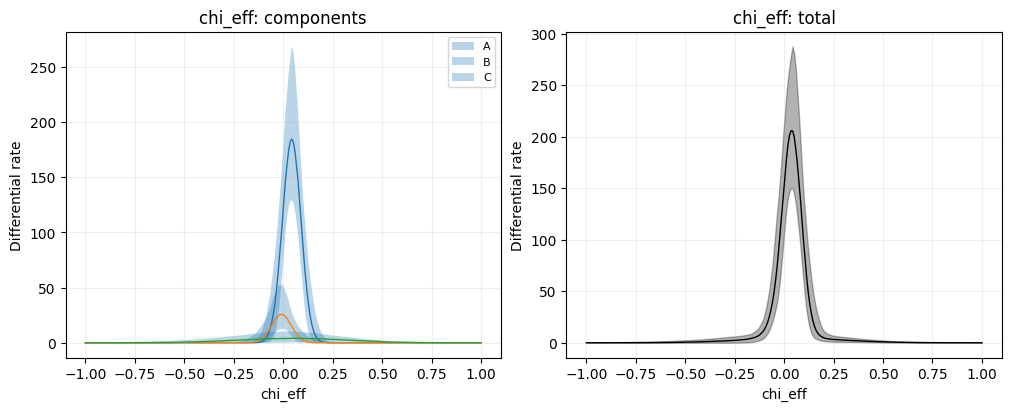

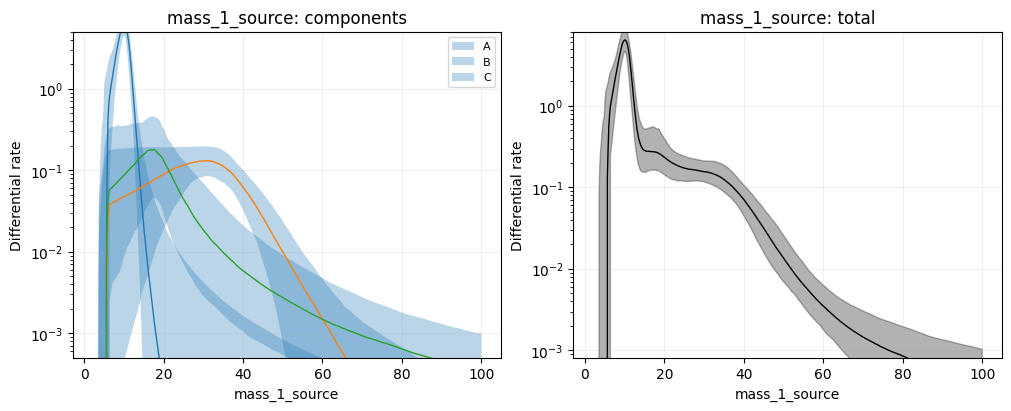

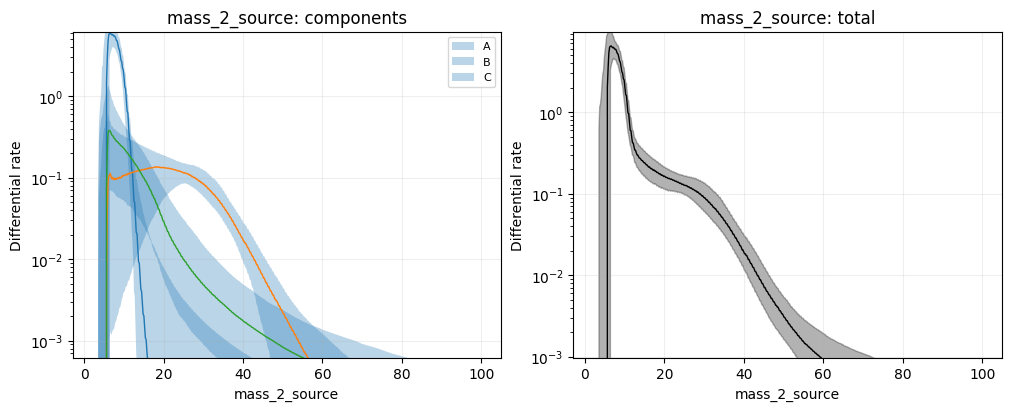

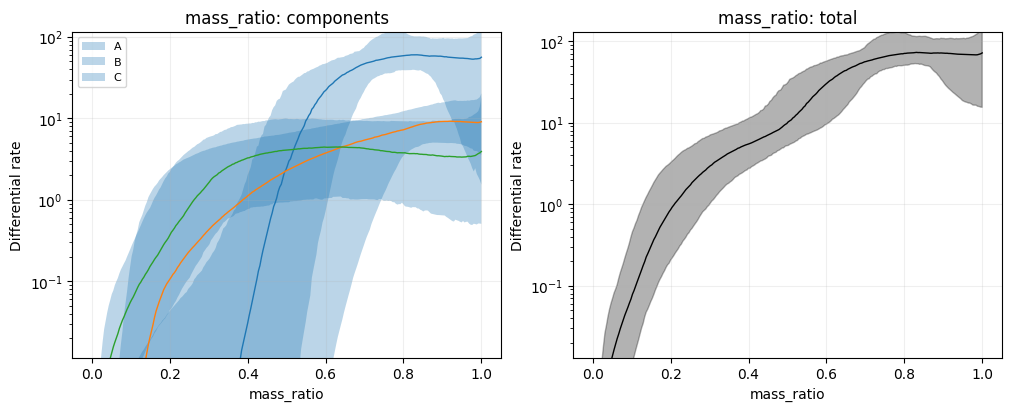

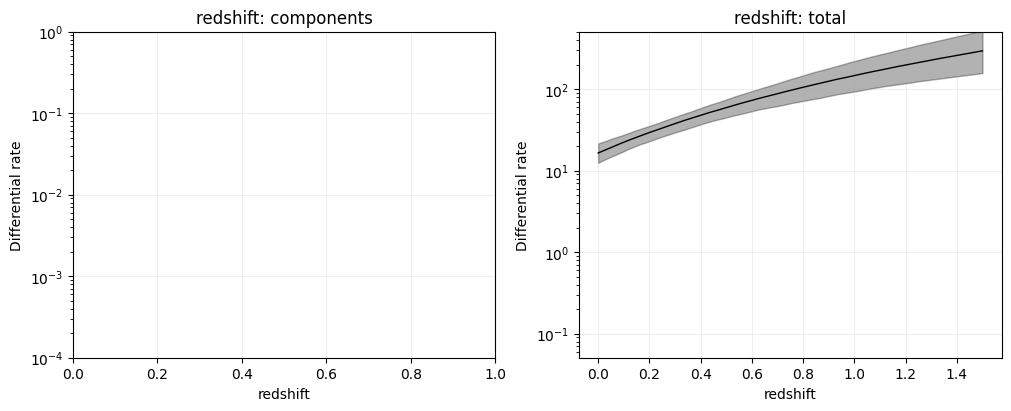

In [4]:
def group_rate_keys_by_param(res, keys, only_1d=True):
    groups = {}
    for key in keys:
        try:
            positions, rates, params = res.get_rates_on_grids(key, return_params=True)
        except Exception as e:
            print(f'Skipping {key}: {e}')
            continue
        params = list(params) if isinstance(params, (list, tuple, np.ndarray)) else [params]
        if only_1d and len(params) != 1:
            continue
        pname = params[0]
        g = groups.setdefault(pname, {'total_key': None, 'component_keys': []})
        if key == pname:
            g['total_key'] = key
        else:
            g['component_keys'].append(key)
    return groups

def load_grid_and_rates(res, key):
    positions, rates, params = res.get_rates_on_grids(key, return_params=True)
    positions = np.atleast_2d(positions)
    if positions.shape[0] != 1:
        raise ValueError(f'Grid for {key} is not 1D (params={params})')
    x = positions[0]
    order = np.argsort(x)
    return x[order], np.asarray(rates)[:, order], params

def plot_rate_ppds(ax, x, rates, color=None, label=None, ci=90, alpha_fill=0.3, lw=1, ls='-'):
    rates = np.asarray(rates)
    if rates.ndim == 1:
        order = np.argsort(x)
        ax.plot(np.asarray(x)[order], rates[order], color=color, lw=lw, ls=ls, label=label)
        return
    dist = (100 - ci) / 2
    low, med, high = np.nanpercentile(rates, [dist, 50, 100 - dist], axis=0)
    order = np.argsort(x)
    x1 = np.asarray(x)[order]
    low, med, high = low[order], med[order], high[order]
    ax.fill_between(x1, low, high, color=color, alpha=alpha_fill, label=label)
    ax.plot(x1, med, color=color, lw=lw, ls=ls)

def set_log_4dex(ax, y_top_hint=None):
    # Enforce log scale with exactly 4 decades visible.
    ax.set_yscale('log')
    if (y_top_hint is None) or (not np.isfinite(y_top_hint)) or (y_top_hint <= 0):
        # Fallback: infer from current lines if possible
        ydata = []
        for ln in ax.get_lines():
            y = np.asarray(ln.get_ydata())
            y = y[np.isfinite(y) & (y > 0)]
            if y.size:
                ydata.append(np.max(y))
        if ydata:
            y_top_hint = np.max(ydata)
        else:
            y_top_hint = 1.0
    y_top = float(y_top_hint)
    y_bot = y_top / 1e4
    # Avoid zero or negative
    if not np.isfinite(y_bot) or y_bot <= 0:
        y_bot = 1e-12
    ax.set_ylim(y_bot, y_top)

def robust_top_from_highs(high_arrays):
    if not high_arrays:
        return None
    vals = np.concatenate([np.asarray(h).ravel() for h in high_arrays])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return None
    return np.quantile(vals, 0.99)

def plot_components_and_total(res, groups, ci=90, figsize=(10,4)):
    for pname, g in groups.items():
        fig, (axc, axt) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
        log_scale = (pname != 'chi_eff')
        comp_highs = []
        # components
        for k in sorted(g['component_keys']):
            try:
                x, rates, _ = load_grid_and_rates(res, k)
            except Exception as e:
                print(f'Skipping component {k}: {e}')
                continue
            # compute highs for scaling
            dist = (100 - ci) / 2
            _, _, high = np.nanpercentile(rates, [dist, 50, 100 - dist], axis=0)
            comp_highs.append(high)
            label = k[len(pname)+1:] if k.startswith(pname + '_') else k
            plot_rate_ppds(axc, x, rates, label=label, ci=ci)
        axc.set_title(f'{pname}: components')
        axc.set_xlabel(pname)
        axc.set_ylabel('Differential rate')
        if axc.get_legend_handles_labels()[0]:
            axc.legend(fontsize=8)
        axc.grid(True, alpha=0.2)
        if log_scale:
            set_log_4dex(axc, y_top_hint=robust_top_from_highs(comp_highs))
        # total
        if g.get('total_key') is not None:
            try:
                x, rates, _ = load_grid_and_rates(res, g['total_key'])
                # compute highs for scaling
                dist = (100 - ci) / 2
                _, _, high_t = np.nanpercentile(rates, [dist, 50, 100 - dist], axis=0)
                plot_rate_ppds(axt, x, rates, color='k', label='total', ci=ci)
                if log_scale:
                    set_log_4dex(axt, y_top_hint=robust_top_from_highs([high_t]))
            except Exception as e:
                print(f'Skipping total {g['total_key']}: {e}')
        axt.set_title(f'{pname}: total')
        axt.set_xlabel(pname)
        axt.set_ylabel('Differential rate')
        axt.grid(True, alpha=0.2)
        plt.show()

groups = group_rate_keys_by_param(res, all_keys, only_1d=True)
print('Parameters with 1D rates:', list(groups.keys()))
plot_components_and_total(res, groups, ci=90)


## 2D contours (median PPD)
- Uses 2D `rates_on_grids` entries if present in the popsummary.
- Draws tricontours of the median across hyper-samples.
- Component overlay opacities scale like sqrt(relative rate), normalized to 1 (similar to main script).


2D parameter pairs found: [('mass_1_source', 'chi_eff'), ('mass_1_source', 'mass_ratio'), ('mass_2_source', 'mass_1_source'), ('mass_ratio', 'chi_eff')]


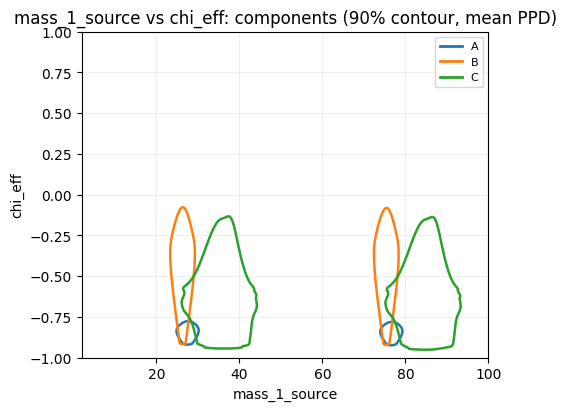

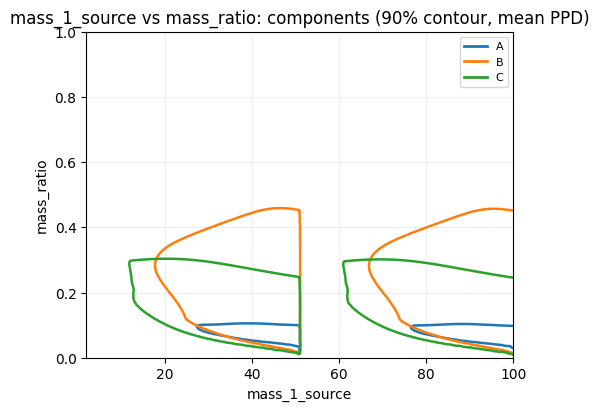

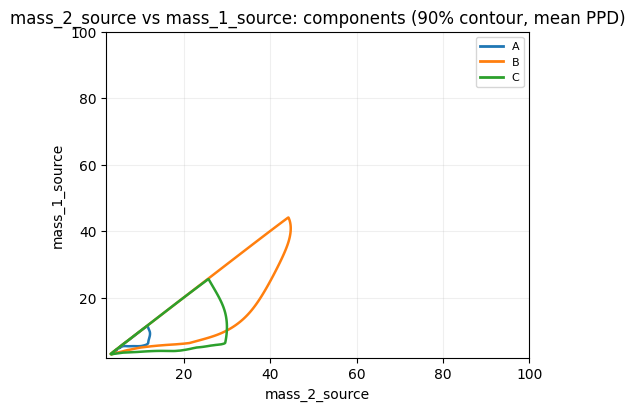

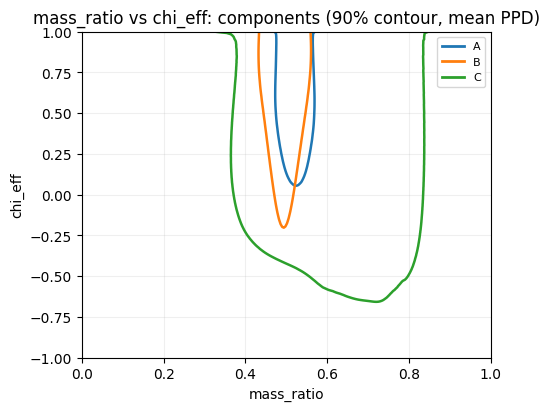

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D

# Aggregation method for combining hyper-samples into a surface per gridpoint
AGG_2D_SURFACE = 'mean'  # 'mean' (matches main script) or 'median'


def group_2d_rate_keys_by_pair(res, keys):
    groups = {}  # {(p1,p2): {'total_key': None, 'component_keys': []}}
    for key in keys:
        try:
            positions, rates, params = res.get_rates_on_grids(key, return_params=True)
        except Exception as e:
            print(f'Skipping {key}: {e}')
            continue
        params = list(params) if isinstance(params, (list, tuple, np.ndarray)) else [params]
        if len(params) != 2:
            continue
        pair = tuple(params)
        base1 = f"{pair[0]}_{pair[1]}_joint"
        base2 = f"{pair[1]}_{pair[0]}_joint"
        g = groups.setdefault(pair, {'total_key': None, 'component_keys': []})
        # Strict naming: total is exactly *_joint, components are *_joint_<label>
        if key == base1 or key == base2:
            g['total_key'] = key
        elif key.startswith(base1 + "_") or key.startswith(base2 + "_"):
            g['component_keys'].append(key)
        else:
            # Unrecognized naming for this pair: ignore to avoid mis-grouping
            continue
    return groups


def load_2d_grid_and_rates(res, key):
    positions, rates, params = res.get_rates_on_grids(key, return_params=True)
    positions = np.atleast_2d(positions)
    if positions.shape[0] != 2:
        raise ValueError(f'Grid for {key} is not 2D (params={params})')
    x, y = positions[0], positions[1]
    x = np.asarray(x).ravel(); y = np.asarray(y).ravel()
    rates = np.asarray(rates)  # (nhypers, npts)
    return x, y, rates, tuple(params)


def comp_label_from_key(key, pair):
    base1 = f"{pair[0]}_{pair[1]}_joint_"
    base2 = f"{pair[1]}_{pair[0]}_joint_"
    if key.startswith(base1):
        return key[len(base1):]
    if key.startswith(base2):
        return key[len(base2):]
    return key


def compute_surface(rates, agg: str = AGG_2D_SURFACE):
    if agg == 'median':
        return np.nanpercentile(rates, 50, axis=0)
    return np.nanmean(rates, axis=0)


def as_rect_grid(x, y, z):
    """If (x,y) lie on a rectangular grid, return (xu, yu, Z[ny,nx]); else None."""
    x = np.asarray(x).ravel(); y = np.asarray(y).ravel(); z = np.asarray(z).ravel()
    xu = np.unique(x); yu = np.unique(y)
    nx, ny = xu.size, yu.size
    if nx * ny != x.size:
        return None
    xi = np.searchsorted(xu, x); yi = np.searchsorted(yu, y)
    if not (np.allclose(xu[xi], x) and np.allclose(yu[yi], y)):
        return None
    Z = np.full((ny, nx), np.nan)
    Z[yi, xi] = z
    return xu, yu, Z


def edge_deltas(v):
    v = np.asarray(v)
    if v.size == 1:
        return np.array([1.0])
    dv = np.empty_like(v, dtype=float)
    dv[1:-1] = 0.5 * (v[2:] - v[:-2])
    dv[0] = v[1] - v[0]
    dv[-1] = v[-1] - v[-2]
    return np.clip(dv, a_min=np.finfo(float).eps, a_max=None)


def vertex_areas_from_triangulation(tri: mtri.Triangulation):
    # Compute per-vertex area as 1/3 of adjacent triangle areas
    tris = tri.triangles
    x = tri.x; y = tri.y
    x1, y1 = x[tris[:, 0]], y[tris[:, 0]]
    x2, y2 = x[tris[:, 1]], y[tris[:, 1]]
    x3, y3 = x[tris[:, 2]], y[tris[:, 2]]
    areas = 0.5 * np.abs(x1*(y2 - y3) + x2*(y3 - y1) + x3*(y1 - y2))
    w = np.zeros_like(x)
    # accumulate 1/3 of each triangle's area to its vertices
    np.add.at(w, tris[:, 0], areas / 3.0)
    np.add.at(w, tris[:, 1], areas / 3.0)
    np.add.at(w, tris[:, 2], areas / 3.0)
    # avoid zeros
    w = np.clip(w, a_min=np.finfo(float).eps, a_max=None)
    return w


def hdi_threshold_weighted(z, w, prob=0.9):
    # Weighted HDR threshold: sum_{z>=t} z*w approx = prob * sum(z*w)
    z = np.asarray(z).ravel(); w = np.asarray(w).ravel()
    m = np.isfinite(z) & np.isfinite(w) & (w > 0)
    z = z[m]; w = w[m]
    if z.size == 0:
        return None
    mass = z * w
    order = np.argsort(z)[::-1]
    z_sorted = z[order]; mass_sorted = mass[order]
    csum = np.cumsum(mass_sorted)
    total = csum[-1]
    if not np.isfinite(total) or total <= 0:
        return None
    idx = int(np.searchsorted(csum, prob * total, side='left'))
    idx = np.clip(idx, 0, z_sorted.size - 1)
    t = float(z_sorted[idx])
    return t if np.isfinite(t) and t > 0 else None


def plot_2d_components_90(res, groups2d, figsize=(5, 4), agg: str = AGG_2D_SURFACE):
    for pair, g in groups2d.items():
        if not g['component_keys']:
            continue
        # Load all components for this pair
        comp_data = []  # list of (label, x, y, surface)
        for k in sorted(g['component_keys']):
            try:
                x, y, rates, params = load_2d_grid_and_rates(res, k)
            except Exception as e:
                print(f'Skipping component {k}: {e}')
                continue
            surf = compute_surface(rates, agg=agg)
            label = comp_label_from_key(k, pair)
            comp_data.append((label, x, y, surf))
        if not comp_data:
            continue
        # Color cycle
        colors = plt.rcParams.get('axes.prop_cycle', None)
        colors = colors.by_key()['color'] if colors is not None else ['C0', 'C1', 'C2', 'C3', 'C4']
        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        handles = []
        for i, (label, x, y, surf) in enumerate(comp_data):
            color = colors[i % len(colors)]
            grid = as_rect_grid(x, y, surf)
            if grid is not None:
                xu, yu, Z = grid
                dx = edge_deltas(xu); dy = edge_deltas(yu)
                W = np.outer(dy, dx)
                t90 = hdi_threshold_weighted(Z, W, prob=0.9)
                if t90 is None:
                    continue
                X, Y = np.meshgrid(xu, yu)
                ax.contour(X, Y, Z, levels=[t90], colors=[color], linewidths=1.8)
            else:
                tri = mtri.Triangulation(x, y)
                w = vertex_areas_from_triangulation(tri)
                t90 = hdi_threshold_weighted(surf, w, prob=0.9)
                if t90 is None:
                    continue
                ax.tricontour(tri, surf, levels=[t90], colors=[color], linewidths=1.8)
            handles.append(Line2D([0], [0], color=color, lw=2, label=label))
        ax.set_xlabel(pair[0])
        ax.set_ylabel(pair[1])
        ax.set_title(f'{pair[0]} vs {pair[1]}: components (90% contour, {agg} PPD)')
        if handles:
            ax.legend(handles=handles, fontsize=8, loc='best')
        ax.grid(True, alpha=0.2)
        plt.show()


def plot_2d_total_90(res, groups2d, figsize=(5, 4), agg: str = AGG_2D_SURFACE):
    for pair, g in groups2d.items():
        k = g.get('total_key')
        if not k:
            continue
        try:
            x, y, rates, params = load_2d_grid_and_rates(res, k)
        except Exception as e:
            print(f'Skipping total {k}: {e}')
            continue
        surf = compute_surface(rates, agg=agg)
        grid = as_rect_grid(x, y, surf)
        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        if grid is not None:
            xu, yu, Z = grid
            dx = edge_deltas(xu); dy = edge_deltas(yu)
            W = np.outer(dy, dx)
            t90 = hdi_threshold_weighted(Z, W, prob=0.9)
            if t90 is None:
                plt.close(fig); continue
            X, Y = np.meshgrid(xu, yu)
            ax.contour(X, Y, Z, levels=[t90], colors='k', linewidths=1.8)
        else:
            tri = mtri.Triangulation(x, y)
            w = vertex_areas_from_triangulation(tri)
            t90 = hdi_threshold_weighted(surf, w, prob=0.9)
            if t90 is None:
                plt.close(fig); continue
            ax.tricontour(tri, surf, levels=[t90], colors='k', linewidths=1.8)
        ax.set_xlabel(pair[0])
        ax.set_ylabel(pair[1])
        ax.set_title(f'{pair[0]} vs {pair[1]}: total (90% contour, {agg} PPD)')
        ax.grid(True, alpha=0.2)
        plt.show()


groups_2d = group_2d_rate_keys_by_pair(res, all_keys)
print('2D parameter pairs found:', list(groups_2d.keys()))
plot_2d_components_90(res, groups_2d, agg=AGG_2D_SURFACE)
plot_2d_total_90(res, groups_2d, agg=AGG_2D_SURFACE)